In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.9 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LwOcuUbYyMAVUxDeqN1v")
project = rf.workspace("mohamed-alaa-tmpkt").project("new-fruits-dnhhw")
version = project.version(2)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to New-Fruits-2 in yolov8:: 100%|██████████| 12123/12123 [00:02<00:00, 4143.70it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from roboflow import Roboflow
from ultralytics import YOLO

In [4]:
print("Dataset Location:")
print(dataset.location)
print("\nFiles:")
print(os.listdir(dataset.location))

Dataset Location:
/content/New-Fruits-2

Files:
['train', 'valid', 'data.yaml', 'test', 'README.dataset.txt', 'README.roboflow.txt']


In [5]:
yaml_path = os.path.join(dataset.location, "data.yaml")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

data

{'names': ['apple',
  'banana',
  'cherry',
  'coconut',
  'cucumber',
  'grape',
  'kiwi',
  'mango',
  'melon',
  'orange',
  'peach',
  'pear',
  'pineapple',
  'pomegranate',
  'rambutan',
  'strawberry',
  'watermelon'],
 'nc': 17,
 'roboflow': {'license': 'CC BY 4.0',
  'project': 'new-fruits-dnhhw',
  'url': 'https://universe.roboflow.com/mohamed-alaa-tmpkt/new-fruits-dnhhw/dataset/2',
  'version': 2,
  'workspace': 'mohamed-alaa-tmpkt'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

In [6]:
train_images = list(Path(dataset.location+"/train/images").glob("*"))
val_images = list(Path(dataset.location+"/valid/images").glob("*"))
test_images = list(Path(dataset.location+"/test/images").glob("*"))

print(f"Training Images : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")
print(f"Testing Images : {len(test_images)}")

Training Images : 4933
Validation Images : 615
Testing Images : 511


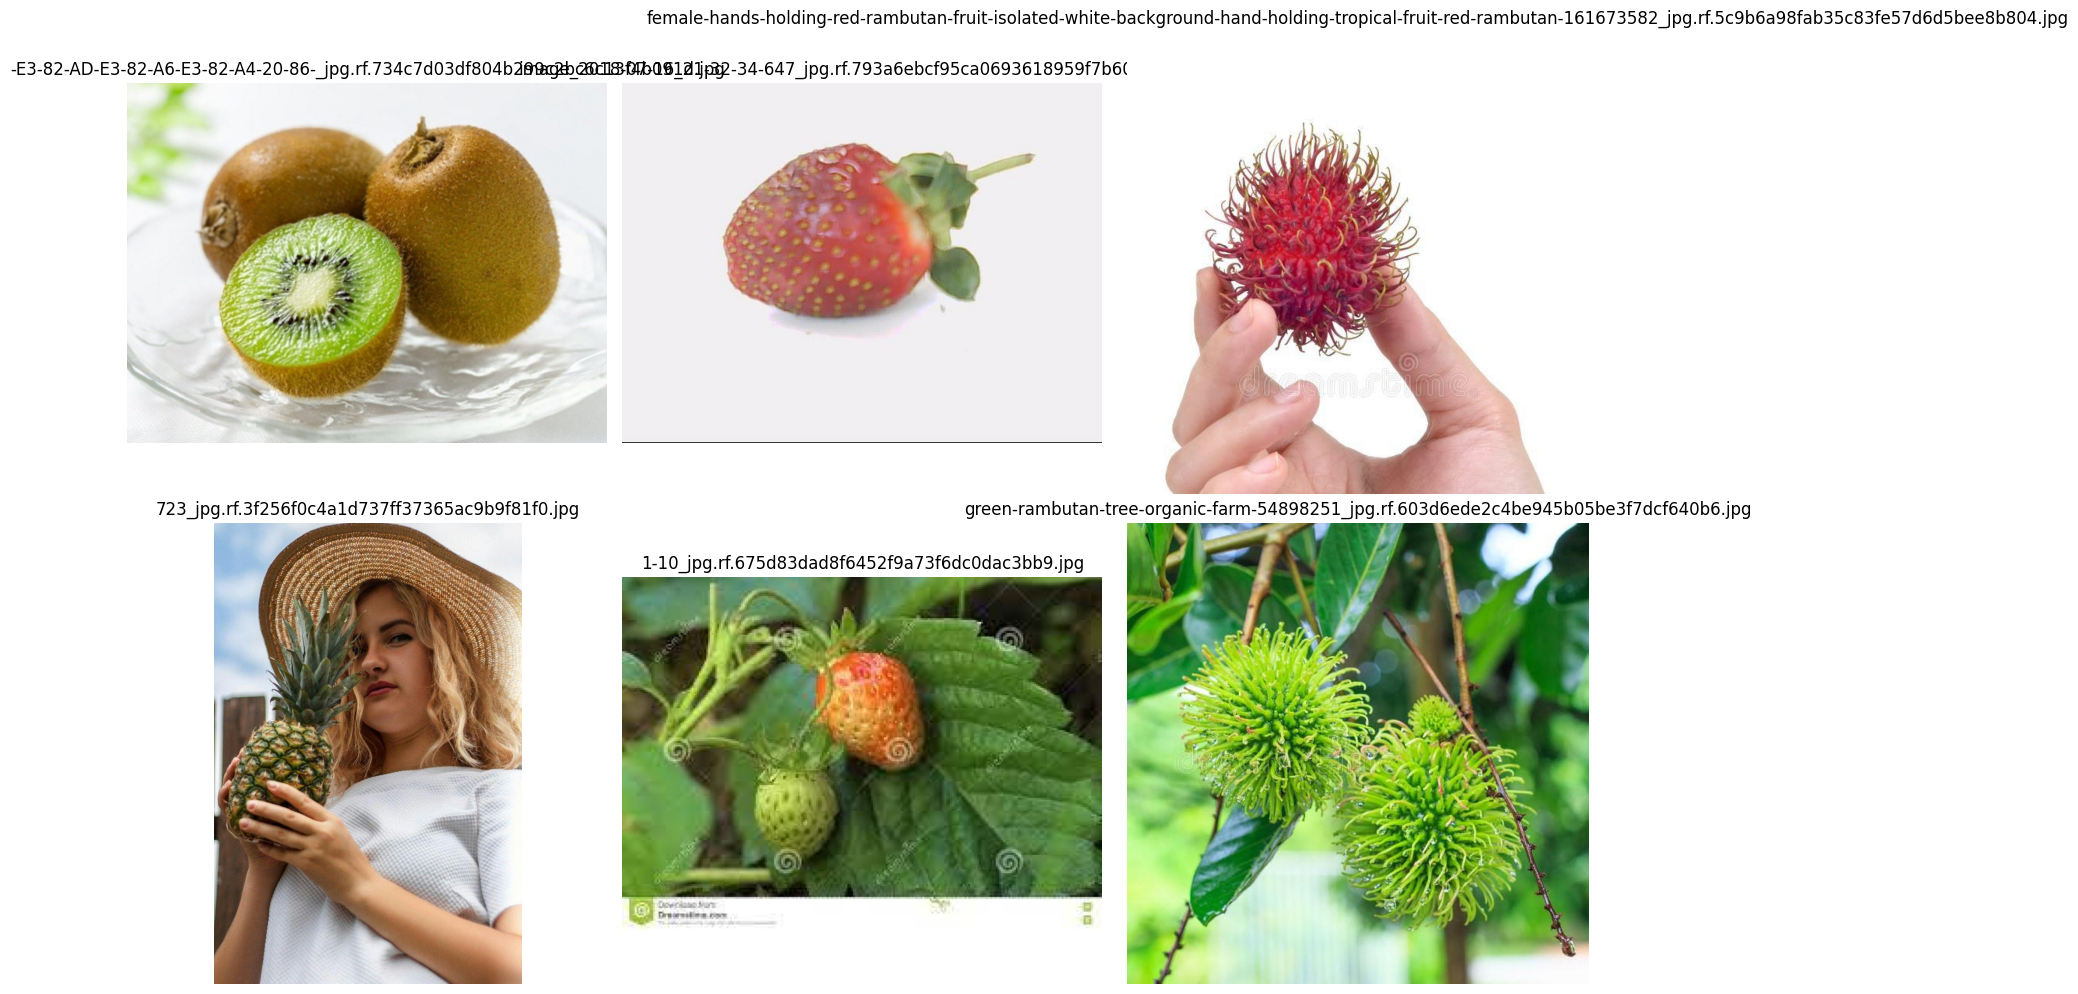

In [7]:
fig, axes = plt.subplots(2,3, figsize=(15,10))

samples = random.sample(train_images,6)

for ax,img_path in zip(axes.flatten(),samples):

    img=cv2.imread(str(img_path))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

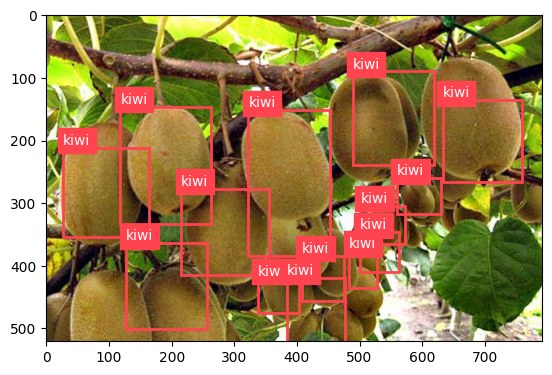

In [8]:
from ultralytics.data.utils import visualize_image_annotations

sample=random.choice(train_images)

label=str(sample).replace("/images/","/labels/")
label=Path(label).with_suffix(".txt")

visualize_image_annotations(str(sample),str(label),data["names"])

In [9]:
model = YOLO("yolov8n.pt")

In [12]:
results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    workers=2,
    project="YOLO_Project",
    name="Version_1",
    save=True,
    save_period=10,
    patience=15,
    plots=True
)

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/New-Fruits-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Version_1-2, nbs=64, nms=False

In [13]:
!ls -R /content/runs/detect/YOLO_Project/Version_1

/content/runs/detect/YOLO_Project/Version_1:
args.yaml   train_batch0.jpg  train_batch2.jpg
labels.jpg  train_batch1.jpg  weights

/content/runs/detect/YOLO_Project/Version_1/weights:


In [14]:
from pathlib import Path

run_dir = Path("/content/runs/detect/YOLO_Project/Version_1")

print(run_dir)

for file in sorted(run_dir.iterdir()):
    print(file.name)

/content/runs/detect/YOLO_Project/Version_1
args.yaml
labels.jpg
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
weights


In [15]:
metrics = model.val()

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,963 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1176.0±843.1 MB/s, size: 25.6 KB)
val: Scanning /content/New-Fruits-2/valid/labels.cache... 615 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 615/615 215.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.9it/s 8.0s
                   all        615       1337      0.771       0.79      0.826      0.586
                 apple         11         31      0.941      0.968      0.985      0.908
                banana         88        147      0.365      0.476      0.449      0.197
                cherry          7         12      0.751      0.667      0.721      0.521
               coconut         18         31      0.881          1      0.987      0.841
              cucumber         15         

In [16]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.8264804272131144
mAP50-95: 0.5856592374448752
Precision: 0.7706284948880342
Recall: 0.7899158158864964


In [17]:
results = model.predict(
    source=random.choice(train_images),
    conf=0.25,
    save=True
)


image 1/1 /content/New-Fruits-2/train/images/-137-_jpg.rf.c62ba95f9fdd5790abe3c38930c41b2f.jpg: 640x480 1 strawberry, 40.3ms
Speed: 2.9ms preprocess, 40.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


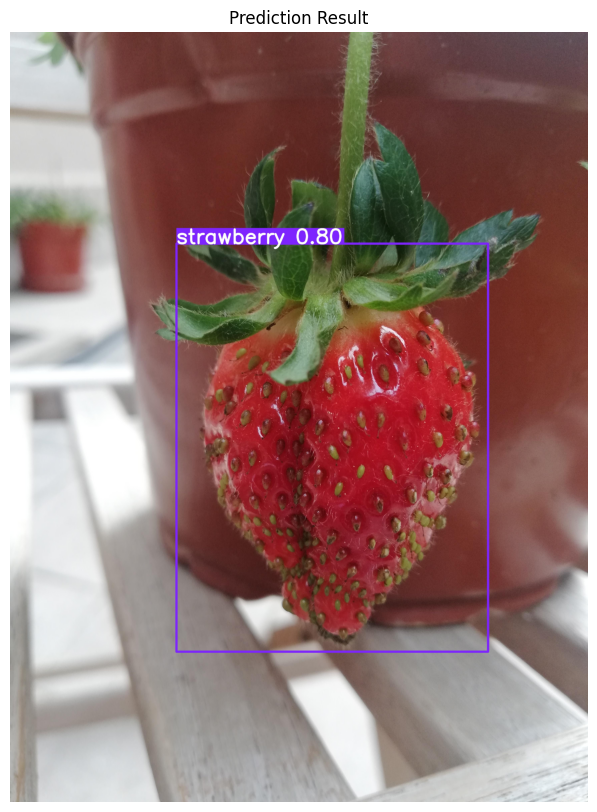

In [18]:
predict_dir = Path("/content/runs/detect/predict")

pred = list(predict_dir.glob("*"))[0]

img = cv2.imread(str(pred))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.title("Prediction Result")
plt.show()

In [24]:
!find /content -name "best.pt"

/content/runs/detect/YOLO_Project/Version_1-2/weights/best.pt


In [25]:
run_dir = Path("/content/runs/detect/YOLO_Project/Version_1-2")
weights = run_dir / "weights"
print("Best :", weights / "best.pt")
print("Last :", weights / "last.pt")

Best : /content/runs/detect/YOLO_Project/Version_1-2/weights/best.pt
Last : /content/runs/detect/YOLO_Project/Version_1-2/weights/last.pt


In [26]:
from google.colab import files

files.download(str(weights/"best.pt"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
print("TRAINING SUMMARY")

print(f"Classes        : {len(data['names'])}")
print(f"Train Images   : {len(train_images)}")
print(f"Valid Images   : {len(val_images)}")
print(f"Test Images    : {len(test_images)}")
print(f"Image Size     : 640x640")
print(f"Epochs         : 50")
print(f"Model          : YOLOv8n")
print(f"Best mAP50     : {metrics.box.map50:.4f}")
print(f"Best mAP50-95  : {metrics.box.map:.4f}")
print(f"Precision      : {metrics.box.mp:.4f}")
print(f"Recall         : {metrics.box.mr:.4f}")

TRAINING SUMMARY
Classes        : 17
Train Images   : 4933
Valid Images   : 615
Test Images    : 511
Image Size     : 640x640
Epochs         : 50
Model          : YOLOv8n
Best mAP50     : 0.8265
Best mAP50-95  : 0.5857
Precision      : 0.7706
Recall         : 0.7899
